# 03 · Metrics — the type drives the variance (built by hand)

**NB 03** of the curriculum (`ROADMAP.md`). NB 02 taught the throughline: under randomization,
difference-in-means recovers the ATE for **every** outcome type. So what does the type change? The
**variance / the correct confidence interval** — and getting it wrong silently breaks coverage (your
CIs lie). This notebook builds, by hand, the **typed metric layer**:

- a **metric is a governed object** — `name · version · type · class · direction` — and the **`type`
  routes to the right variance** (the Netflix lesson, LYRA §4);
- **proportion** → two-proportion $z$; **ratio** → the **delta method** (the star: naive iid
  *under-covers*); **CUPED** → variance reduction with no bias; **quantile** → bootstrap;
- the **A/A test** is the metric's promotion gate (a good metric shows *no* effect under the null).

We consume the **DGP zoo** (`lyra/dgp`) from NB 02 so every claim is checked against a known truth.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dataclasses import dataclass

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from lyra.dgp import BinaryDGP, RevenueDGP

Z = 1.959963985


# the raw coverage harness (NB01-style): repeat the experiment, ask if the CI covers the known truth
def coverage_check(estimate_fn, simulate, truth, R=400, n=4000, seed0=1000):
    pts, cov, wid, rej = [], [], [], []
    for r in range(R):
        d, (lo, hi) = estimate_fn(simulate(n, seed0 + r))
        pts.append(d); cov.append(lo <= truth <= hi); wid.append(hi - lo); rej.append(not (lo <= 0 <= hi))
    pts = np.array(pts)
    return dict(bias=pts.mean() - truth, coverage=np.mean(cov), ci_width=np.mean(wid),
                reject_rate=np.mean(rej), points=pts)

## 1. A metric is a typed, versioned object

Mature orgs (Netflix, Airbnb) hit one failure mode: "churn" computed three different ways across
experiments, so tests *look* comparable but aren't. The fix is governance — a metric is **defined
once, versioned, and carries its `type`** — and the type is what selects the correct variance. We
model the spec as a small record; §6 wires `type → estimator`.

In [2]:
@dataclass(frozen=True)
class MetricSpec:
    name: str
    version: int
    type: str            # "mean" | "proportion" | "ratio" | "quantile" | "count"
    cls: str             # "primary" | "secondary" | "guardrail"
    direction: str = "up"   # "up" = higher is better

conversion = MetricSpec("conversion_rate", 1, "proportion", "primary")
gmv_per_session = MetricSpec("gmv_per_session", 1, "ratio", "primary")
print(conversion); print(gmv_per_session)

MetricSpec(name='conversion_rate', version=1, type='proportion', cls='primary', direction='up')
MetricSpec(name='gmv_per_session', version=1, type='ratio', cls='primary', direction='up')


## 2. Proportion metrics — the variance is $p(1-p)$

For a binary metric the correct standard error uses the Bernoulli variance, not a generic spread:
$$\widehat{\Delta}=\hat p_1-\hat p_0,\qquad
  \widehat{\mathrm{se}}=\sqrt{\tfrac{\hat p_1(1-\hat p_1)}{n_1}+\tfrac{\hat p_0(1-\hat p_0)}{n_0}}$$
— the **two-proportion $z$**. We check it on the zoo's `BinaryDGP` (true risk difference ≈ 0.104).

In [3]:
def two_prop_z(df):
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    p1, p0 = t.mean(), c.mean(); d = p1 - p0
    se = np.sqrt(p1 * (1 - p1) / t.size + p0 * (1 - p0) / c.size)
    return d, (d - Z * se, d + Z * se)

binary = BinaryDGP(); truth_b = binary.ground_truth().ate
rep = coverage_check(two_prop_z, binary.sample, truth_b, R=400, n=6000)
print(f"proportion (two-prop z): truth {truth_b:.4f}  bias {rep['bias']:+.4f}  coverage {rep['coverage']:.2f}")

proportion (two-prop z): truth 0.1044  bias -0.0004  coverage 0.95


## 3. Ratio metrics — the delta method (the headline)

The trap: the **randomization unit is the user**, but the metric is measured **per session** —
*GMV/session*, *clicks/page*. The pooled ratio is
$$\hat\theta=\frac{\sum_i \text{conv}_i}{\sum_i \text{sessions}_i}.$$
Sessions from the *same user* are correlated (a heavy user is heavy across all their sessions), so
treating sessions as iid Bernoulli **under-states the variance** → CIs too narrow → coverage collapses.
The **delta method** (Deng–Knoblich–Lu 2018) linearises the ratio at the **user level**:
$$\widehat{\mathrm{Var}}(\hat\theta)=\frac{1}{K\,\bar n^2}
  \Big(s_Y^2 - 2\hat\theta\,s_{YN} + \hat\theta^2 s_N^2\Big),$$
with $K$ users, per-user numerator $Y_i$ / denominator $N_i$, $\bar n=\overline{N_i}$, and
$s_Y^2,s_N^2,s_{YN}$ the user-level (co)variances. We author a ratio world **with user heterogeneity**
so the trap bites.

In [4]:
def sim_ratio(n, seed, dcr=0.02, cr0=0.20, user_sigma=0.20, lam=9):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < 0.5).astype(int)
    sessions = 1 + rng.poisson(lam, n)                 # sessions per user (the random denominator)
    u = rng.normal(0, user_sigma, n)                   # user-level heterogeneity → within-user correlation
    cr = np.clip(cr0 + u + dcr * treat, 0.001, 0.999)  # per-user, per-session conversion prob
    conversions = rng.binomial(sessions, cr)
    return pd.DataFrame({"treat": treat, "sessions": sessions, "conversions": conversions})

def _delta_arm(num, den):
    K, nbar, theta = len(num), den.mean(), num.sum() / den.sum()
    var = (num.var(ddof=1) - 2 * theta * np.cov(num, den)[0, 1] + theta ** 2 * den.var(ddof=1)) / (K * nbar ** 2)
    return theta, var

def delta_ratio(df):                                   # CORRECT: user-level delta method
    a, b = df[df.treat == 1], df[df.treat == 0]
    t1, v1 = _delta_arm(a.conversions.to_numpy(), a.sessions.to_numpy())
    t0, v0 = _delta_arm(b.conversions.to_numpy(), b.sessions.to_numpy())
    d = t1 - t0; se = np.sqrt(v1 + v0); return d, (d - Z * se, d + Z * se)

def naive_ratio(df):                                   # WRONG: treat every session as iid Bernoulli
    def arm(s):
        N = s.sessions.sum(); th = s.conversions.sum() / N; return th, th * (1 - th) / N
    t1, v1 = arm(df[df.treat == 1]); t0, v0 = arm(df[df.treat == 0])
    d = t1 - t0; se = np.sqrt(v1 + v0); return d, (d - Z * se, d + Z * se)

truth_r = 0.02
naive = coverage_check(naive_ratio, sim_ratio, truth_r, R=500, n=4000)
delta = coverage_check(delta_ratio, sim_ratio, truth_r, R=500, n=4000)
print(f"naive (session-iid):  bias {naive['bias']:+.4f}  coverage {naive['coverage']:.2f}  CI width {naive['ci_width']:.4f}")
print(f"delta (user-level) :  bias {delta['bias']:+.4f}  coverage {delta['coverage']:.2f}  CI width {delta['ci_width']:.4f}")

naive (session-iid):  bias -0.0030  coverage 0.74  CI width 0.0164
delta (user-level) :  bias -0.0030  coverage 0.94  CI width 0.0271


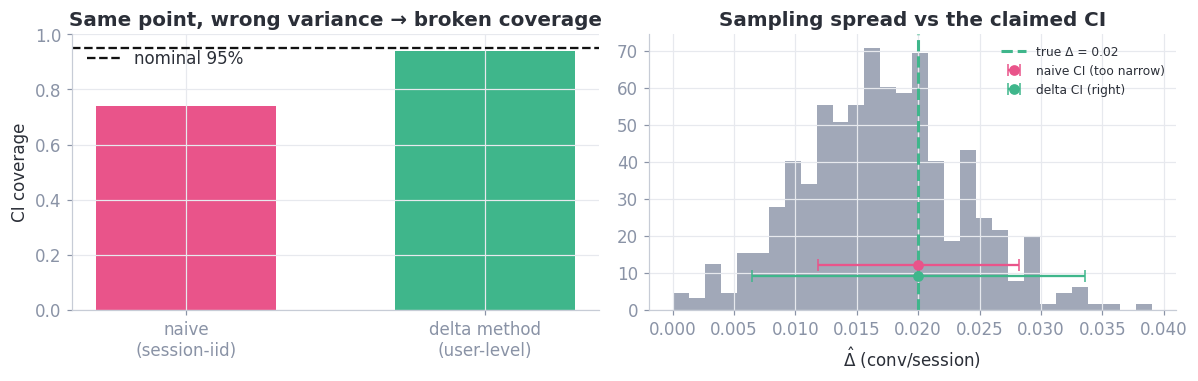

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["naive\n(session-iid)", "delta method\n(user-level)"], [naive["coverage"], delta["coverage"]],
          color=[PINK, GREEN], width=.6)
ax[0].axhline(0.95, color="#111", ls="--", lw=1.5, label="nominal 95%")
ax[0].set_ylim(0, 1); ax[0].set_ylabel("CI coverage"); ax[0].set_title("Same point, wrong variance → broken coverage"); ax[0].legend()
ax[1].hist(naive["points"], bins=30, density=True, color=GRAY, alpha=.8)
ax[1].axvline(truth_r, color=GREEN, ls="--", lw=2, label="true Δ = 0.02")
# overlay the two CI half-widths to show naive is too narrow
ax[1].errorbar(truth_r, 12, xerr=naive["ci_width"]/2, fmt="o", color=PINK, capsize=4, label="naive CI (too narrow)")
ax[1].errorbar(truth_r, 9, xerr=delta["ci_width"]/2, fmt="o", color=GREEN, capsize=4, label="delta CI (right)")
ax[1].set_xlabel(r"$\hat\Delta$ (conv/session)"); ax[1].set_title("Sampling spread vs the claimed CI"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The naive CI covers truth only ~**73%** of the time (it claims 95%) — the classic *false precision*
that ships bad launches. The delta method restores ~95%. Same point estimate, **right error bars**.
This is *why* the metric layer must know `type=ratio`.

## 4. CUPED — variance reduction with a pre-period (no bias)

If we have a **pre-experiment** covariate $X$ correlated with the outcome, we can subtract its
predictable part. CUPED (Deng et al. 2013) forms
$$Y^{\text{cuped}}=Y-\theta\,(X-\bar X),\qquad \theta=\frac{\mathrm{Cov}(Y,X)}{\mathrm{Var}(X)},$$
which is **unbiased** (X is pre-treatment, equal in expectation across arms) and cuts variance by a
factor $1-\rho^2$ where $\rho=\mathrm{corr}(Y,X)$. We author a pre/post world with $\rho\approx0.7$.

plain Welch : bias +0.0007  coverage 0.95  CI width 0.1432
CUPED       : bias +0.0013  coverage 0.94  CI width 0.1022
variance reduction ≈ 49%  (≈ rho^2 = 49%)


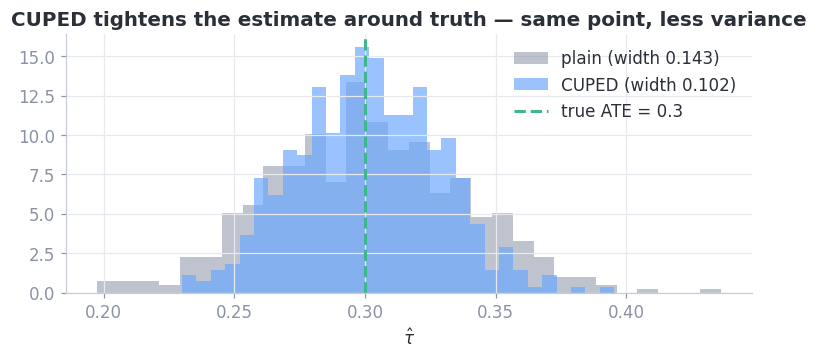

In [6]:
def sim_prepost(n, seed, ate=0.3, rho=0.7):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < 0.5).astype(int)
    x_pre = rng.normal(0, 1, n)                                       # pre-period covariate
    y = 5.0 + rho * x_pre + ate * treat + rng.normal(0, np.sqrt(1 - rho ** 2), n)
    return pd.DataFrame({"treat": treat, "y": y, "x_pre": x_pre})

def welch_mean(df):
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    d = t.mean() - c.mean(); se = np.sqrt(t.var(ddof=1) / t.size + c.var(ddof=1) / c.size)
    return d, (d - Z * se, d + Z * se)

def cuped_mean(df):
    x, y = df.x_pre.to_numpy(), df.y.to_numpy()
    theta = np.cov(y, x)[0, 1] / x.var(ddof=1)
    ya = y - theta * (x - x.mean())                                  # variance-reduced outcome
    t, c = ya[df.treat == 1], ya[df.treat == 0]
    d = t.mean() - c.mean(); se = np.sqrt(t.var(ddof=1) / t.size + c.var(ddof=1) / c.size)
    return d, (d - Z * se, d + Z * se)

plain = coverage_check(welch_mean, sim_prepost, 0.3, R=500, n=3000)
cuped = coverage_check(cuped_mean, sim_prepost, 0.3, R=500, n=3000)
vr = 1 - (cuped["ci_width"] / plain["ci_width"]) ** 2
print(f"plain Welch : bias {plain['bias']:+.4f}  coverage {plain['coverage']:.2f}  CI width {plain['ci_width']:.4f}")
print(f"CUPED       : bias {cuped['bias']:+.4f}  coverage {cuped['coverage']:.2f}  CI width {cuped['ci_width']:.4f}")
print(f"variance reduction ≈ {vr:.0%}  (≈ rho^2 = {0.7**2:.0%})")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(plain["points"], bins=30, density=True, alpha=.55, color=GRAY, label=f"plain (width {plain['ci_width']:.3f})")
ax.hist(cuped["points"], bins=30, density=True, alpha=.7, color=BLUE, label=f"CUPED (width {cuped['ci_width']:.3f})")
ax.axvline(0.3, color=GREEN, ls="--", lw=2, label="true ATE = 0.3")
ax.set_xlabel(r"$\hat\tau$"); ax.set_title("CUPED tightens the estimate around truth — same point, less variance"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Quantile metrics — bootstrap the CI

Some OECs are **quantiles** (p90 latency, median spend) — no neat closed-form SE, so we **bootstrap**
the quantile treatment effect. We use the zoo's heavy-tailed `RevenueDGP` and the p90 of spenders.

In [7]:
def p90_bootstrap(df, B=400, q=0.90, seed=0):
    rng = np.random.default_rng(seed)
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    d = np.quantile(t, q) - np.quantile(c, q)
    boots = [np.quantile(rng.choice(t, t.size), q) - np.quantile(rng.choice(c, c.size), q) for _ in range(B)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return d, (lo, hi)

rev = RevenueDGP().sample(8000, seed=1)
d90, (lo, hi) = p90_bootstrap(rev)
print(f"p90 revenue treatment effect = {d90:+.3f}   bootstrap 95% CI [{lo:+.3f}, {hi:+.3f}]")

p90 revenue treatment effect = +3.209   bootstrap 95% CI [+1.724, +5.581]


## 6. The registry routes `type → variance`, and A/A is the gate

Tie it together: the spec's **`type` selects the estimator**, so defining the metric correctly is
*what makes the variance correct* (Layer 4 → Layer 5). And a metric only earns promotion if it passes
an **A/A test** — run on data with **no** real effect, a trustworthy metric flags at the nominal
$\alpha=5\%$, and its p-values are **uniform**. A metric that flags more is leaky/broken.

A/A false-positive rate (target ≈ 0.05):
  proportion       reject rate 0.048
  ratio (delta)    reject rate 0.047
  ratio (naive)    reject rate 0.217  <-- LEAKY (over-flags)
  mean (CUPED)     reject rate 0.053


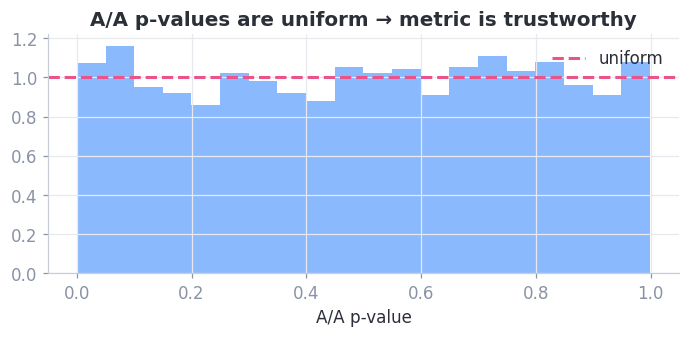

In [8]:
ESTIMATORS = {"proportion": two_prop_z, "ratio": delta_ratio, "mean": welch_mean}

def evaluate(spec, df):
    return ESTIMATORS[spec.type](df)

# A/A: same DGPs with the effect switched OFF — reject rates should sit at ~5%
aa = {
    "proportion": coverage_check(two_prop_z, lambda n, s: BinaryDGP(beta=0.0).sample(n, s), 0.0, R=600, n=6000),
    "ratio (delta)": coverage_check(delta_ratio, lambda n, s: sim_ratio(n, s, dcr=0.0), 0.0, R=600, n=4000),
    "ratio (naive)": coverage_check(naive_ratio, lambda n, s: sim_ratio(n, s, dcr=0.0), 0.0, R=600, n=4000),
    "mean (CUPED)": coverage_check(cuped_mean, lambda n, s: sim_prepost(n, s, ate=0.0), 0.0, R=600, n=3000),
}
print("A/A false-positive rate (target ≈ 0.05):")
for k, r in aa.items():
    flag = "  <-- LEAKY (over-flags)" if r["reject_rate"] > 0.08 else ""
    print(f"  {k:16s} reject rate {r['reject_rate']:.3f}{flag}")

# p-value uniformity for the proportion metric under A/A (the classic check)
rng = np.random.default_rng(0)
pvals = []
for r in range(2000):
    df = BinaryDGP(beta=0.0).sample(4000, 5000 + r)
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    p1, p0 = t.mean(), c.mean(); se = np.sqrt(p1 * (1 - p1) / t.size + p0 * (1 - p0) / c.size)
    pvals.append(2 * (1 - stats.norm.cdf(abs(p1 - p0) / se)))
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(pvals, bins=20, density=True, color=BLUE, alpha=.8); ax.axhline(1.0, color=PINK, ls="--", lw=2, label="uniform")
ax.set_xlabel("A/A p-value"); ax.set_title("A/A p-values are uniform → metric is trustworthy"); ax.legend()
plt.tight_layout(); plt.show()

The delta-method ratio passes A/A (~5%); the **naive** ratio **over-flags** (its broken variance both
under-covers *and* false-positives) — A/A catches exactly the bug §3 diagnosed. The proportion metric's
A/A p-values are uniform: a clean bill of health.

## 7. Promote → `lyra/metrics.py`

We lift the typed estimators + the `MetricSpec` + the `type → estimator` router into `lyra/metrics.py`,
behind the same `Estimator` contract, so the **harness certifies each metric type** and the scorecard
can bind experiments to a metric **version**. We verify the promoted code reproduces the headline —
the clustered ratio (`RatioDGP(user_sigma=0.2)`, now a knob on the zoo world): delta covers, naive doesn't.

In [9]:
from lyra.dgp import RatioDGP, PrePostDGP
from lyra.metrics import MetricSpec, RatioMetric, NaiveRatioMetric, MeanMetric, CupedMetric, estimator_for
from lyra.harness import harness

clustered = RatioDGP(dcr=0.02, user_sigma=0.20)
print("promoted lyra.metrics on the clustered ratio world (truth 0.02):")
print(f"  delta method : coverage {harness(RatioMetric(), clustered, R=300, n=4000)['coverage']:.2f}")
print(f"  naive        : coverage {harness(NaiveRatioMetric(), clustered, R=300, n=4000)['coverage']:.2f}  <- under-covers")
pp = PrePostDGP(ate=0.3, rho=0.7)
w_plain = harness(MeanMetric(), pp, R=300, n=3000)["ci_width"]; w_cuped = harness(CupedMetric(), pp, R=300, n=3000)["ci_width"]
print(f"  CUPED variance reduction: {1-(w_cuped/w_plain)**2:.0%}")
print(f"  registry: type 'ratio' -> {type(estimator_for(MetricSpec('gmv_ps',1,'ratio','primary'))).__name__}")

promoted lyra.metrics on the clustered ratio world (truth 0.02):
  delta method : coverage 0.92
  naive        : coverage 0.79  <- under-covers
  CUPED variance reduction: 49%
  registry: type 'ratio' -> RatioMetric


✅ **Promoted** (covered by `tests/test_metrics.py`; full suite green). The metric layer now knows that
`type=ratio` ⇒ delta method and `type=proportion` ⇒ two-prop z — *defining the metric right is what
makes the variance right*. **Next (`ROADMAP.md`): NB 04 — cluster-robust standard errors** (the other
half of "correct variance": correlated *units* — the jackknife / CV3 / wild cluster bootstrap).